In [48]:
import numpy as np
import seaborn as sns
import pandas as pd
import os

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error as rmse

In [83]:
hourly_data = '../data/schedule_data/processed_data/by_hour'
hourly_data_list = [x for x in os.listdir(hourly_data) if x[-4:] == '.csv']
dtypes = pd.read_csv(f'{os.path.join(hourly_data,hourly_data_list[0])}', nrows=1).iloc[0].to_dict()
print(dtypes)

{'stop': 'object', 'EB/WB': 'object', 'time': 'datetime64[ns]', 'bunch': 'int64', 'gap': 'int64', 'dt short': 'float64', 'dt long': 'float64'}


In [87]:
dtypes = {'stop': 'string', 'EB/WB': 'string', 'time': 'string', 'bunch': 'int64', 'gap': 'int64', 'dt short': 'float64', 'dt long': 'float64'}

In [88]:
dataframes = [pd.read_csv(os.path.join(hourly_data,x),dtype=dtypes, skiprows=[1]) for x in hourly_data_list]
daily_df = pd.concat(dataframes, ignore_index=True)

In [89]:
daily_df['time'] = daily_df['time'].apply(pd.Timestamp)
daily_df = daily_df[daily_df['time'] < pd.Timestamp('2025-09-01')]

daily_df = daily_df.rename(columns={'dt short':'dt_short', 'dt long':'dt_long', 'EB/WB':'dir', 'time':'date'})

In [90]:
daily_df.head()

,stop,dir,date,bunch,gap,dt_short,dt_long
600,Augusta Ave,W,2025-01-01 00:00:00,0,0,0.0,0.0
601,Augusta Ave,W,2025-01-01 01:00:00,0,0,0.0,0.0
602,Augusta Ave,W,2025-01-01 02:00:00,0,0,0.0,0.0
603,Augusta Ave,W,2025-01-01 03:00:00,0,0,0.0,0.0
604,Augusta Ave,W,2025-01-01 04:00:00,0,0,0.0,0.0


In [91]:
daily_df.date = daily_df.date.apply(pd.Timestamp)

In [92]:
daily_df.head()

,stop,dir,date,bunch,gap,dt_short,dt_long
600,Augusta Ave,W,2025-01-01 00:00:00,0,0,0.0,0.0
601,Augusta Ave,W,2025-01-01 01:00:00,0,0,0.0,0.0
602,Augusta Ave,W,2025-01-01 02:00:00,0,0,0.0,0.0
603,Augusta Ave,W,2025-01-01 03:00:00,0,0,0.0,0.0
604,Augusta Ave,W,2025-01-01 04:00:00,0,0,0.0,0.0


In [93]:
# I want to add daily weather data.
weather=pd.read_csv('../data/raw_data/Weatherstats_data/weatherstats_toronto_daily.csv')
#drop columns that consist exclusively of NaNs
weather.dropna(axis=1, how='all', inplace=True)
#Convert date from string to datetime type
weather.date = weather.date.apply(pd.Timestamp)

#fill remainder of the NaNs with '0'
weather.fillna(0, inplace=True)

columns = weather.columns
#the following columns have a deterministic relationship with the temperature so we are dropping them
columns = [x for x in columns if 'degdays' not in x]

# Choosing avg stats vs max/min stats
columns = [x for x in columns if 'max' not in x and 'min' not in x]
# Removing 'hourly data'
columns = [x for x in columns if 'hourly' not in x]
# Picking one time format
columns = [x for x in columns if 'sunrise_f' != x and 'sunset_f' != x]
columns = [x for x in columns if 'unixtime' not in x]
# Picking station pressure vs sea pressure
columns = [x for x in columns if 'avg_pressure_sea' != x]


weather['sunrise_hhmm'] = weather['sunrise_hhmm'].apply(pd.Timedelta)
weather['sunset_hhmm'] = weather['sunset_hhmm'].apply(pd.Timedelta)

weather = weather[columns]

In [94]:
first_date = daily_df['date'].min()
last_date = daily_df['date'].max()
weather = weather[weather['date'].between(first_date,last_date)]
weather.head()

,date,avg_temperature,avg_relative_humidity,avg_dew_point,avg_wind_speed,wind_gust_dir_10s,avg_pressure_station,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
174,2025-08-31,16.39,57.5,9.1,8.5,0.0,100.36,24100,2.0,0.0,0.0,0.0,0.0,0 days 06:40:00,0 days 19:55:00,13.25,2.0
175,2025-08-30,15.00,58.5,7.5,13.0,31.0,99.96,24100,2.0,0.0,0.0,0.0,0.0,0 days 06:39:00,0 days 19:57:00,13.30,3.5
176,2025-08-29,13.55,64.5,6.0,19.5,31.0,99.73,24100,1.7,0.0,0.0,0.0,0.0,0 days 06:38:00,0 days 19:59:00,13.35,4.0
177,2025-08-28,14.95,73.5,11.8,17.5,32.0,99.53,18500,2.2,5.4,5.4,0.0,0.0,0 days 06:36:00,0 days 20:00:00,13.40,4.0
178,2025-08-27,17.00,58.0,6.7,19.5,26.0,99.86,24100,2.1,0.0,0.0,0.0,0.0,0 days 06:35:00,0 days 20:02:00,13.45,3.0


In [95]:
daily_df = pd.merge(daily_df, weather, on='date')

In [96]:
daily_df.head()

,stop,dir,date,bunch,gap,dt_short,dt_long,avg_temperature,avg_relative_humidity,avg_dew_point,...,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
0,Augusta Ave,W,2025-01-01,0,0,0.0,0.0,1.29,79.5,-1.5,...,16900,1.6,0.7,0.7,0.0,0.0,0 days 07:51:00,0 days 16:51:00,9.00,7.0
1,Augusta Ave,W,2025-01-02,0,0,0.0,0.0,-1.50,85.0,-4.2,...,12850,1.7,1.8,0.0,1.8,0.0,0 days 07:51:00,0 days 16:52:00,9.02,4.5
2,Augusta Ave,W,2025-01-03,0,0,0.0,0.0,-2.70,64.0,-8.8,...,20100,2.1,0.0,0.0,0.0,1.0,0 days 07:51:00,0 days 16:53:00,9.03,5.5
3,Augusta Ave,W,2025-01-04,0,0,0.0,0.0,-4.40,68.0,-10.1,...,16900,2.4,0.0,0.0,0.0,0.0,0 days 07:51:00,0 days 16:54:00,9.05,5.0
4,Augusta Ave,W,2025-01-05,0,0,0.0,0.0,-3.60,72.5,-8.3,...,21700,2.5,0.0,0.0,0.0,0.0,0 days 07:51:00,0 days 16:55:00,9.07,5.5


In [97]:
daily_df['bunch_lagged'] = daily_df['bunch'].shift(1)

In [98]:
# Fill na values with 0
daily_df.fillna(0, inplace=True)

In [99]:
features = ['dir', 'bunch', 'bunch_lagged','gap']+weather.columns.to_list()
targets = [x for x in daily_df.columns if 'dt_' in x]

In [100]:
corr_matrix = daily_df[features+targets].select_dtypes(np.number).corr()

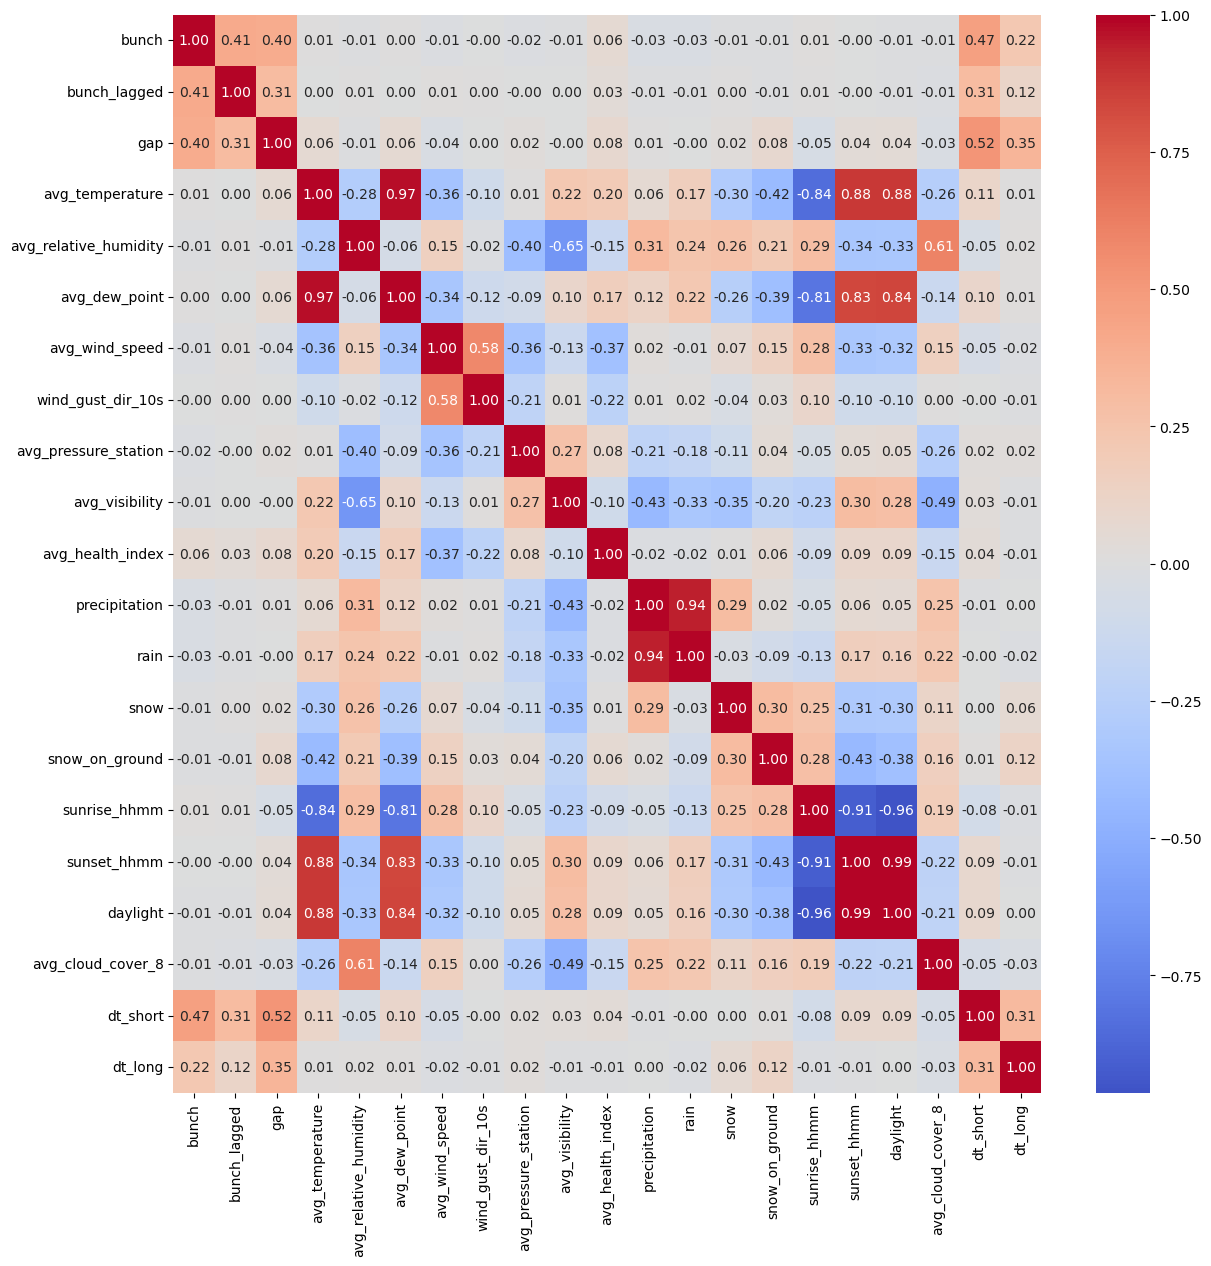

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,14))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f')
plt.show()

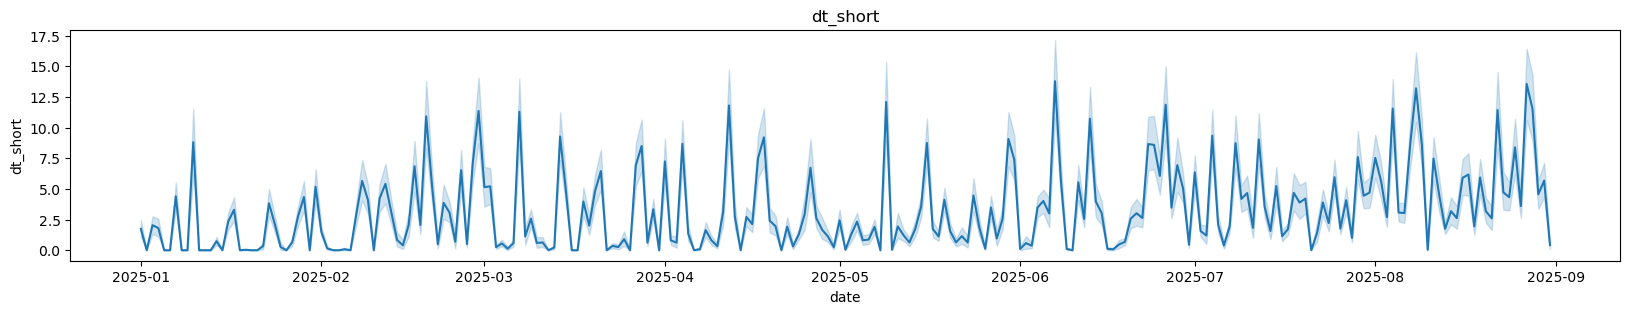

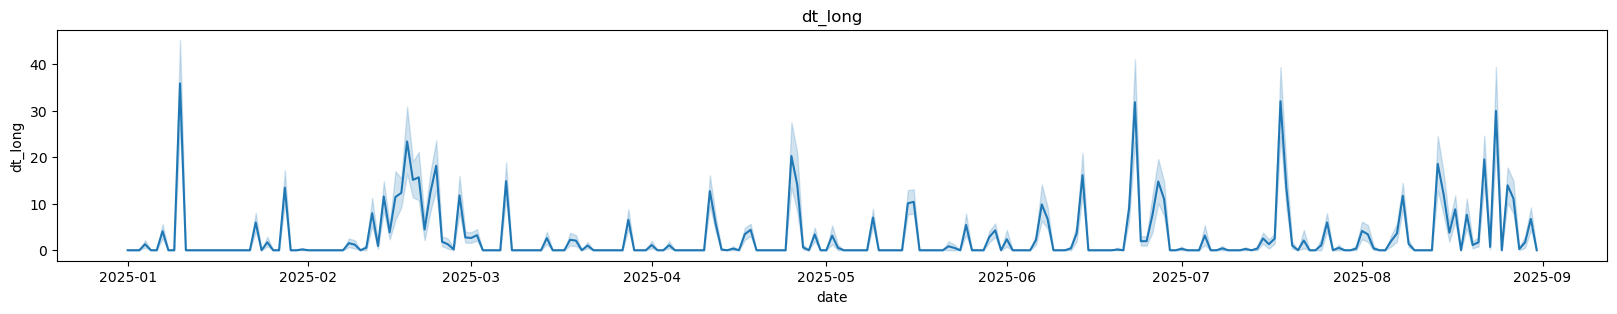

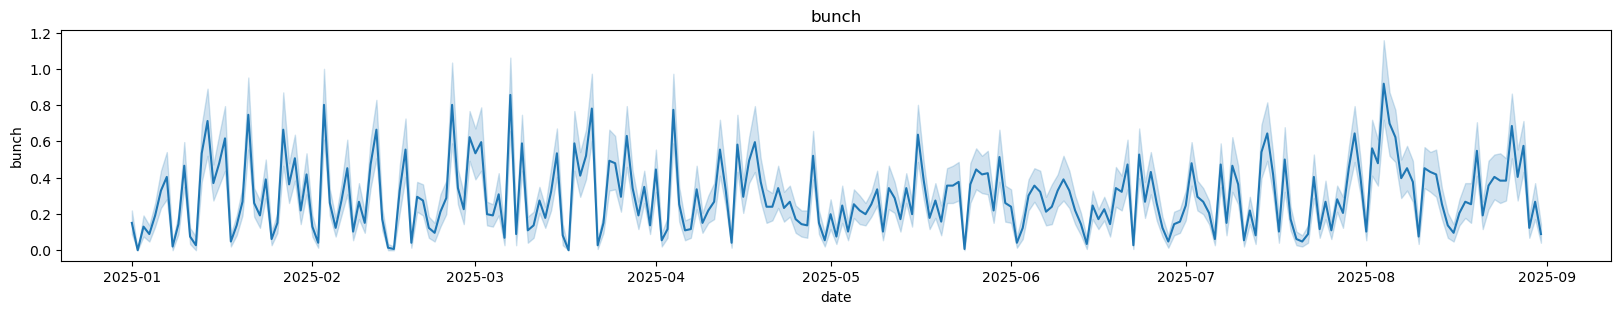

In [116]:
for dt in ['dt_short', 'dt_long']:
    plt.figure(figsize=(20,3))
    sns.lineplot(data=daily_df, x='date', y=dt)
    plt.title(dt)
    plt.show()

plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='bunch')
plt.title('bunch')
plt.show()

Some of the dt_long behaviour can be explained by snow.

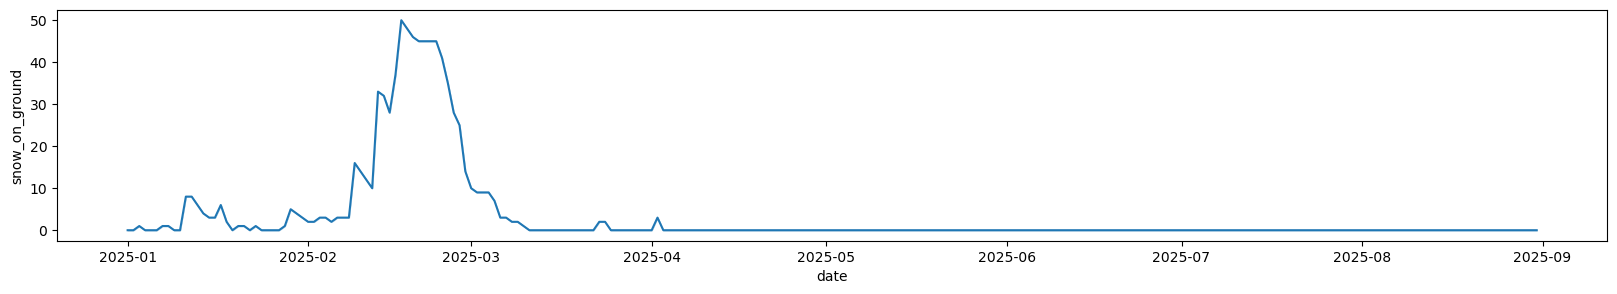

In [104]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='snow_on_ground')
plt.show()

The time of the year can be kept track of through the amount of daylight.

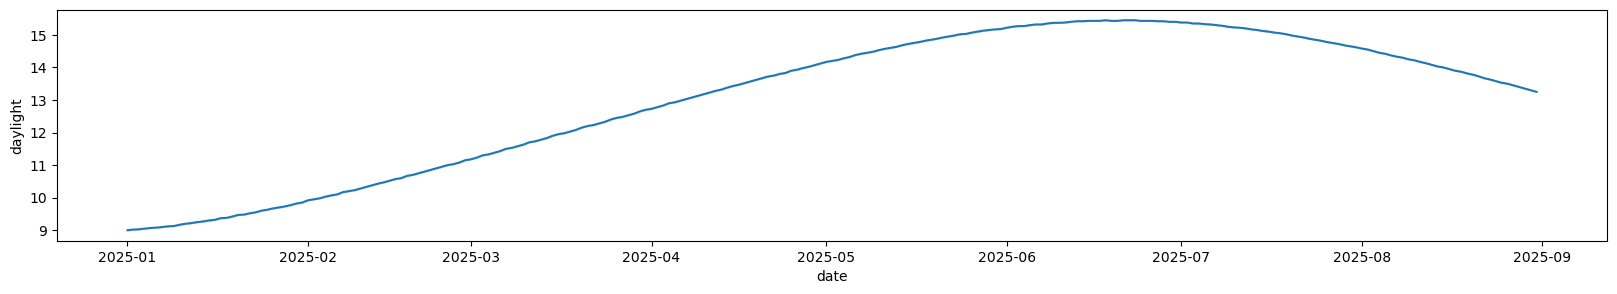

In [106]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='daylight')
plt.show()

In [109]:
def count_feature(date, feature, df):
    if len(df[df['date'] == date][feature].tolist())==0:
        return 0
    else:
        return sum(df[df['date'] == date][feature])

bunch_events = []
start_date = daily_df.date.min()
end_date = daily_df.date.max()
timedelta = (end_date - start_date).days
for delta in range(timedelta):
    bunch_events.append(count_feature(start_date+pd.Timedelta(days=delta), 'bunch', daily_df))

bunch_events = np.array(bunch_events)

The autocorrelation graphs of bunch events show no real correlation.

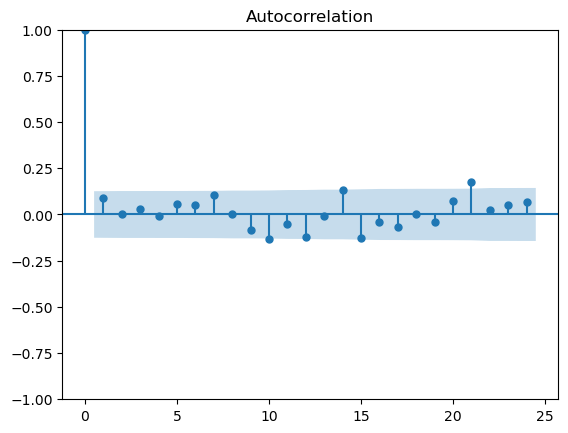

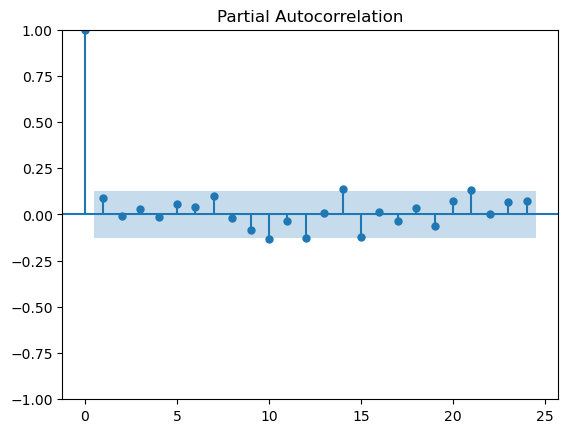

In [110]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
plot_acf(bunch_events)
plt.show()
plot_pacf(bunch_events)
plt.show()

We use xgboost since it's a very flexible model that generalizes well.

In [121]:
# Let's try xgboost since it is a very flexible model
import xgboost as xgb
# First turn stop into a categorical feature.
daily_df['stop']=daily_df['stop'].astype('category')
daily_df['dir']=daily_df['dir'].astype('category')

loss = dict()
R2_score = dict()
features = ['bunch','avg_temperature', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain',
            'snow_on_ground',
            'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
for target in ['dt_short', 'dt_long']:
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=100,
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=20,
                                reg_alpha=20,
                                reg_lambda=0,
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[target,idx] = r2_score(y_test, y_pred)
        loss[target,idx] = rmse(y_test, y_pred)

for dt in ['dt_short', 'dt_long']:
    print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
    print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
    print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
    print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')

dt_short rmse mean: 0.10955512171636028
dt_short rmse std: 0.048549927913033884
dt_short average R^2 score: 0.0
dt_short R^2 score std: 0.0

dt_long rmse mean: 0.09919778641553625
dt_long rmse std: 0.028790570271306295
dt_long average R^2 score: 0.0
dt_long R^2 score std: 0.0

